<a href="https://colab.research.google.com/github/Tanzeel-data/Practice/blob/main/nlp_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Generated vs Human-Written Text Classification using NLP and Machine Learning

---

## Project Overview

The rapid advancement of Large Language Models (LLMs) such as ChatGPT, Gemini, and Claude has transformed the way textual content is generated. While these models produce highly fluent and coherent text, distinguishing AI-generated content from human-written text has become an increasingly important challenge in education, journalism, digital publishing, and online content moderation.

This project presents an end-to-end Natural Language Processing (NLP) pipeline for automatically classifying text as either **AI-generated** or **Human-written**. The project demonstrates the complete workflow of a classical NLP classification task, including data exploration, text preprocessing, feature extraction, machine learning model development, evaluation, and performance comparison.

Classical text representation techniques such as **Bag of Words (Count Vectorizer)**, **TF-IDF**, and **N-Gram models** are used to transform textual data into numerical features. Multiple machine learning algorithms are then trained and evaluated to identify the most effective approach for this binary text classification problem.

---

## Objectives

The primary objectives of this project are:

- Understand the complete NLP pipeline from raw text to prediction.
- Perform comprehensive text preprocessing and normalization.
- Convert textual data into numerical vectors using Count Vectorizer and TF-IDF.
- Explore the effect of different N-Gram representations.
- Train multiple Machine Learning classifiers.
- Evaluate and compare model performance using standard classification metrics.
- Demonstrate the practical application of NLP in detecting AI-generated content.

---

## Expected Workflow

1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Text Preprocessing
5. Feature Engineering
6. Text Vectorization
7. Model Training
8. Model Evaluation
9. Results Comparison
10. N-Gram & Markov Model Discussion
11. Prediction Demo
12. Conclusion

# Problem Statement

With the widespread adoption of advanced Large Language Models (LLMs), automatically distinguishing AI-generated text from human-written text has become a significant challenge. Educational institutions, publishers, businesses, and online platforms require reliable methods to verify content authenticity and reduce misinformation or unauthorized AI-generated submissions.

The objective of this project is to develop a machine learning-based Natural Language Processing (NLP) system capable of classifying a given text as either **AI-generated** or **Human-written**.

---

## Real-World Applications

- Academic integrity and plagiarism detection
- AI-generated content detection
- Journalism and media verification
- Content moderation
- Digital publishing
- Online education platforms
- Research and document authentication

---

## Input

A paragraph or document containing textual content.

### Example

> Artificial Intelligence has transformed modern healthcare by improving diagnosis and personalized treatment.

---

## Output

One of the following classes:

- AI Generated
- Human Written

# Dataset Description

This project uses the **AI vs Human Text Classification Dataset** obtained from Kaggle.

The dataset contains textual samples labeled as either **AI-generated** or **Human-written**, making it suitable for supervised binary text classification.

### Dataset Information

- Dataset Type: Binary Text Classification
- Source: Kaggle
- Text Column: `text`
- Target Column: `label`

The dataset also contains additional statistical features such as word count, character count, average word length, and punctuation density. However, in this project, only the raw text is used for feature extraction because the objective is to build a complete Natural Language Processing pipeline.

---

## Input Feature

- Text

## Target Feature

- Label

Where:

- AI → Text generated using AI models.
- Human → Text written by humans.

In [ ]:
# ==============================
# Import Required Libraries
# ==============================

# Data Handling
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Word Cloud
from wordcloud import WordCloud

# Text Processing
import re
import string

# NLTK
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

# Scikit-Learn
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Plot Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [ ]:
# Download NLTK Resources

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


True

# Load Dataset

In this section, the dataset is loaded into a Pandas DataFrame. The initial inspection helps us understand the structure of the dataset, available features, and target labels before performing any preprocessing or analysis.

In [ ]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/gulfan/ai-vs-human-text-classification-dataset/ai_vs_human_text.csv


In [ ]:


df = pd.read_csv("/kaggle/input/datasets/gulfan/ai-vs-human-text-classification-dataset/ai_vs_human_text.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [ ]:

df.head()

,id,text,label,word_count,char_count,avg_word_length,punctuation_density
0,1,It always seems impossible until it's done.,human,7,43,5.285714,0.142857
1,2,She finished the challenging crossword puzzle.,ai,6,46,6.833333,0.166667
2,3,"You can't use up creativity. The more you use,...",human,13,65,4.076923,0.307692
3,4,The journey of a thousand miles begins with a ...,human,11,58,4.363636,0.090909
4,5,"Life is short, and it is up to you to make it ...",human,13,52,3.076923,0.153846


In [ ]:
print("Dataset Shape:", df.shape)

print(f"\nNumber of Rows : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Dataset Shape: (1299, 7)

Number of Rows : 1299
Number of Columns : 7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1299 entries, 0 to 1298
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1299 non-null   int64  
 1   text                 1299 non-null   object 
 2   label                1299 non-null   object 
 3   word_count           1299 non-null   int64  
 4   char_count           1299 non-null   int64  
 5   avg_word_length      1299 non-null   float64
 6   punctuation_density  1299 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 71.2+ KB


In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [ ]:
print(df.columns.tolist())

['id', 'text', 'label', 'word_count', 'char_count', 'avg_word_length', 'punctuation_density']


# Dataset Exploration


In [ ]:
df['label'].value_counts()

label
human    651
ai       648
Name: count, dtype: int64

In [ ]:
print("Unique Classes:")

print(df['label'].unique())

print()

print("Number of Classes:", df['label'].nunique())

Unique Classes:
['human' 'ai']

Number of Classes: 2


In [ ]:
counts = df['label'].value_counts()

majority = counts.max()
minority = counts.min()

ratio = majority / minority

print(f"Imbalance Ratio : {ratio:.2f}")

if ratio < 1.5:
    print("Dataset is Balanced.")
else:
    print("Dataset is Imbalanced.")

Imbalance Ratio : 1.00
Dataset is Balanced.


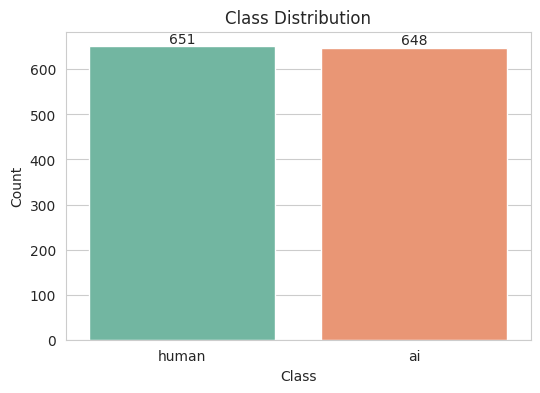

In [ ]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x='label',
    palette='Set2'
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

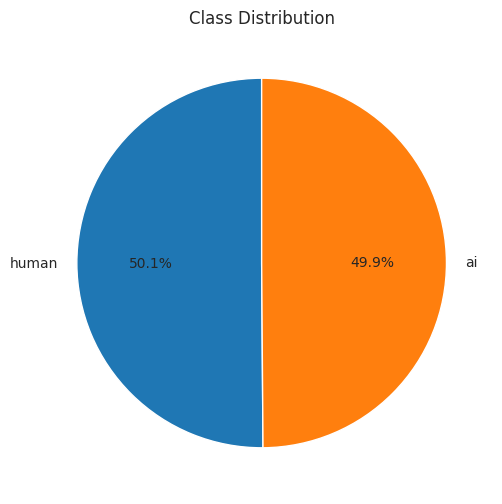

In [ ]:
df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6),
    startangle=90
)

plt.ylabel("")
plt.title("Class Distribution")

plt.show()

In [ ]:
print("Text Column  :", "text")

print("Target Column:", "label")

Text Column  : text
Target Column: label


In [ ]:
print("Text Column  :", "text")

print("Target Column:", "label")

Text Column  : text
Target Column: label


In [ ]:
summary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values
})

summary

,Feature,Data Type,Missing Values
0,id,int64,0
1,text,object,0
2,label,object,0
3,word_count,int64,0
4,char_count,int64,0
5,avg_word_length,float64,0
6,punctuation_density,float64,0


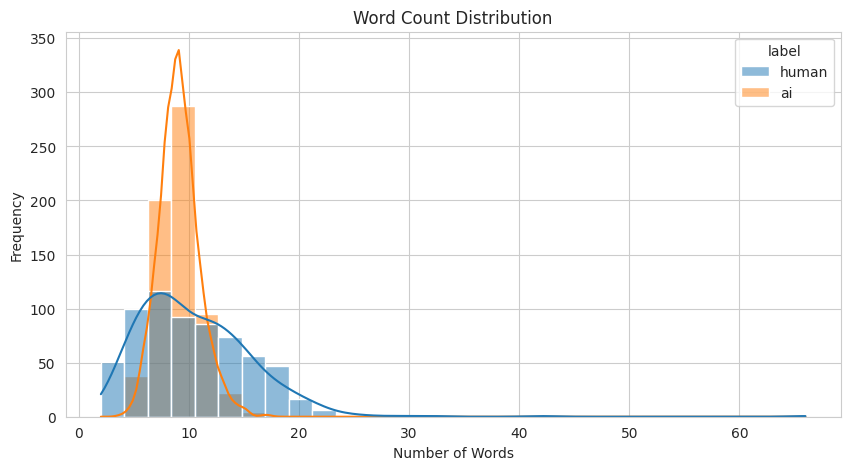

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="word_count",
    bins=30,
    kde=True,
    hue="label"
)

plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

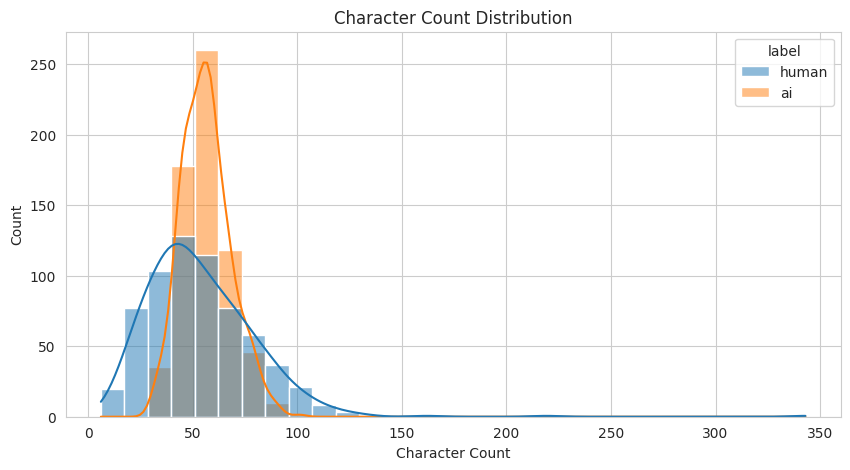

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="char_count",
    bins=30,
    kde=True,
    hue="label"
)

plt.title("Character Count Distribution")
plt.xlabel("Character Count")

plt.show()

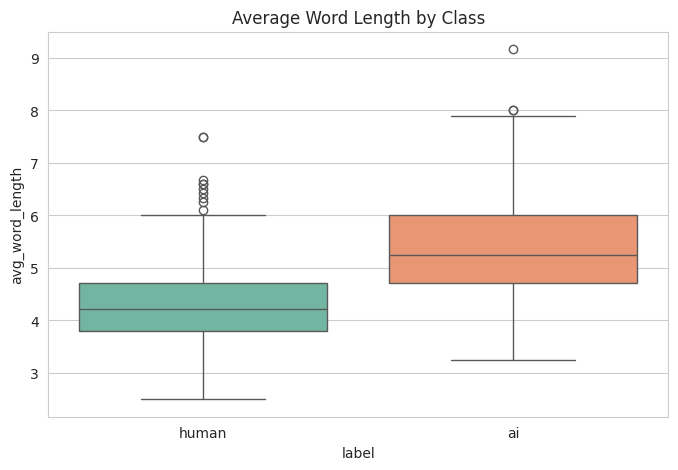

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="avg_word_length",
    palette="Set2"
)

plt.title("Average Word Length by Class")

plt.show()

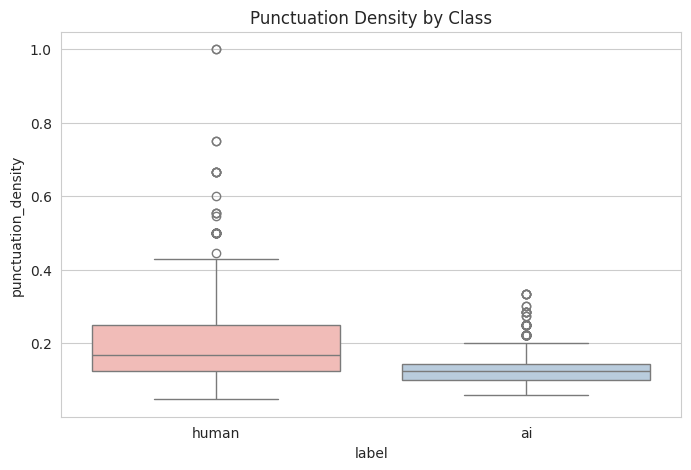

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="punctuation_density",
    palette="Pastel1"
)

plt.title("Punctuation Density by Class")

plt.show()

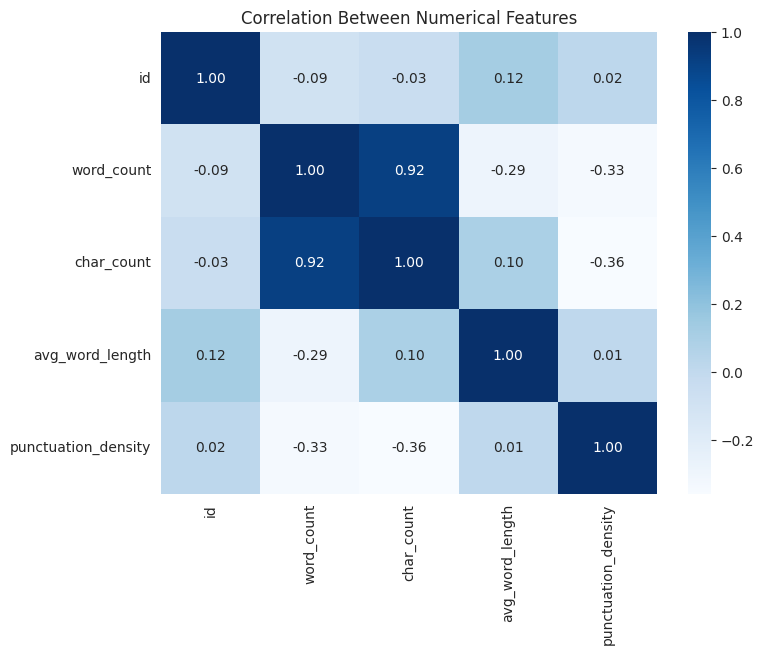

In [ ]:
plt.figure(figsize=(8,6))

numeric = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")

plt.show()

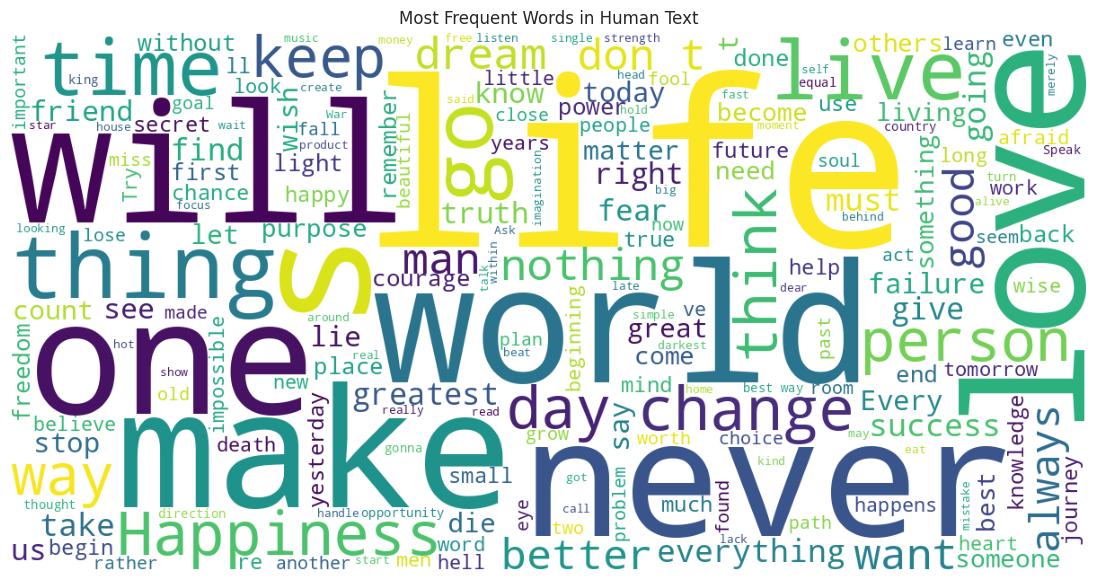

In [ ]:
human_text = " ".join(df[df.label=="human"]["text"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(human_text)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words in Human Text")

plt.show()

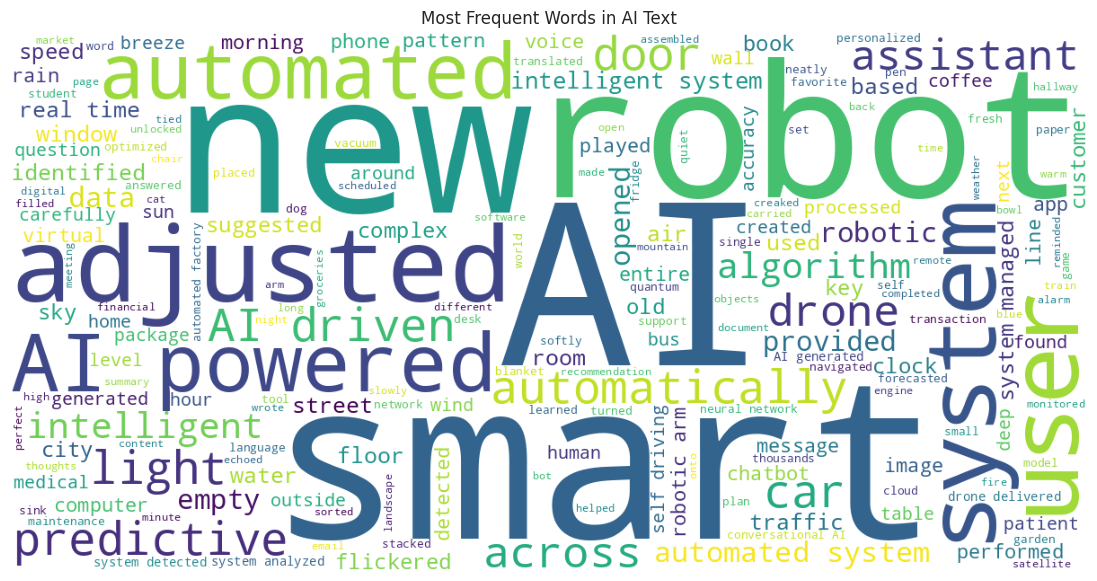

In [ ]:
ai_text = " ".join(df[df.label=="ai"]["text"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(ai_text)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words in AI Text")

plt.show()

In [ ]:
from collections import Counter

def plot_top_words(texts, title):

    words = " ".join(texts).lower().split()

    common = Counter(words).most_common(20)

    words = [w[0] for w in common]
    counts = [w[1] for w in common]

    plt.figure(figsize=(12,6))

    sns.barplot(
        x=counts,
        y=words,
        palette="viridis"
    )

    plt.title(title)

    plt.show()

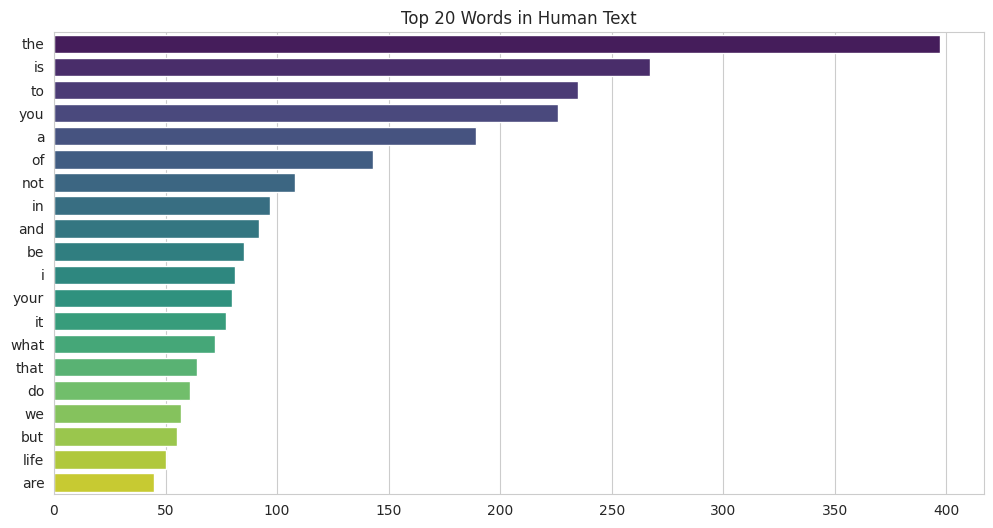

In [ ]:
plot_top_words(
    df[df.label=="human"]["text"],
    "Top 20 Words in Human Text"
)

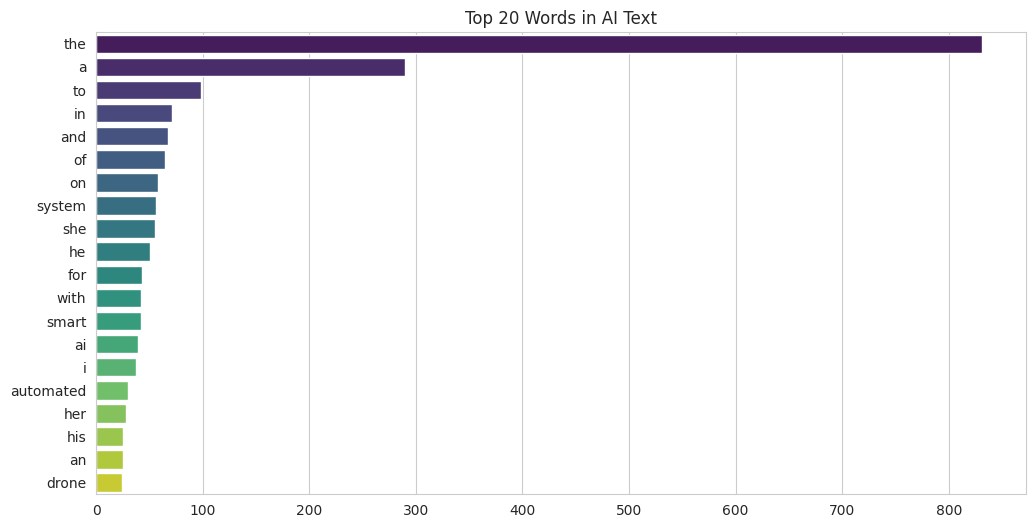

In [ ]:
plot_top_words(
    df[df.label=="ai"]["text"],
    "Top 20 Words in AI Text"
)

# Text Preprocessing


In [ ]:
# Select one sample text for demonstration

sample_text = df.loc[0, "text"]

print("Original Text:\n")
print(sample_text)

Original Text:

It always seems impossible until it's done.


In [ ]:
lower_text = sample_text.lower()

print("After Lowercasing:\n")
print(lower_text)

After Lowercasing:

it always seems impossible until it's done.


In [ ]:
lower_text = sample_text.lower()

no_punct = lower_text.translate(
    str.maketrans('', '', string.punctuation)
)

print("After Removing Punctuation:\n")
print(no_punct)

After Removing Punctuation:

it always seems impossible until its done


In [ ]:
# Recreate previous step so this cell works independently
lower_text = sample_text.lower()

no_punct = lower_text.translate(
    str.maketrans('', '', string.punctuation)
)

no_numbers = re.sub(r'\d+', '', no_punct)

print("After Removing Numbers:\n")
print(no_numbers)

After Removing Numbers:

it always seems impossible until its done


In [ ]:
clean_text = re.sub(r'[^a-zA-Z\s]', '', no_numbers)

print(clean_text)

it always seems impossible until its done


In [ ]:
clean_text = re.sub(r'\s+', ' ', clean_text).strip()

print(clean_text)

it always seems impossible until its done


In [ ]:
sentences = sent_tokenize(sample_text)

print("Total Sentences:", len(sentences))

sentences

Total Sentences: 1


["It always seems impossible until it's done."]

In [ ]:
tokens = word_tokenize(clean_text)

print(tokens)

['it', 'always', 'seems', 'impossible', 'until', 'its', 'done']


In [ ]:
stop_words = set(stopwords.words("english"))

filtered_words = [
    word for word in tokens
    if word not in stop_words
]

print(filtered_words)

['always', 'seems', 'impossible', 'done']


In [ ]:
stemmer = PorterStemmer()

stemmed = [
    stemmer.stem(word)
    for word in filtered_words
]

print(stemmed)

['alway', 'seem', 'imposs', 'done']


In [ ]:
lemmatizer = WordNetLemmatizer()

lemmatized = [
    lemmatizer.lemmatize(word)
    for word in filtered_words
]

print(lemmatized)

['always', 'seems', 'impossible', 'done']


In [ ]:
comparison = pd.DataFrame({
    "Step": [
        "Original",
        "Lowercase",
        "No Punctuation",
        "No Numbers",
        "Clean Text",
        "Tokens",
        "Stopwords Removed",
        "Stemmed",
        "Lemmatized"
    ],
    "Output": [
        sample_text,
        lower_text,
        no_punct,
        no_numbers,
        clean_text,
        " ".join(tokens),
        " ".join(filtered_words),
        " ".join(stemmed),
        " ".join(lemmatized)
    ]
})

comparison

,Step,Output
0,Original,It always seems impossible until it's done.
1,Lowercase,it always seems impossible until it's done.
2,No Punctuation,it always seems impossible until its done
3,No Numbers,it always seems impossible until its done
4,Clean Text,it always seems impossible until its done
5,Tokens,it always seems impossible until its done
6,Stopwords Removed,always seems impossible done
7,Stemmed,alway seem imposs done
8,Lemmatized,always seems impossible done


# Complete Text Preprocessing Pipeline


In [ ]:
# Initialize NLP Objects

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    tokens = word_tokenize(text)

    # Stopword removal + Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

In [ ]:
# Create a new cleaned text column

df["clean_text"] = df["text"].apply(preprocess_text)

df.head()

,id,text,label,word_count,char_count,avg_word_length,punctuation_density,clean_text
0,1,It always seems impossible until it's done.,human,7,43,5.285714,0.142857,always seems impossible done
1,2,She finished the challenging crossword puzzle.,ai,6,46,6.833333,0.166667,finished challenging crossword puzzle
2,3,"You can't use up creativity. The more you use,...",human,13,65,4.076923,0.307692,cant use creativity use
3,4,The journey of a thousand miles begins with a ...,human,11,58,4.363636,0.090909,journey thousand mile begin single step
4,5,"Life is short, and it is up to you to make it ...",human,13,52,3.076923,0.153846,life short make sweet


In [ ]:
empty_rows = (df["clean_text"].str.len() == 0).sum()

print("Empty Text Rows:", empty_rows)

Empty Text Rows: 4


In [ ]:
# Check which rows became empty

empty_rows = df[df["clean_text"].str.strip() == ""]

print("Number of Empty Rows:", len(empty_rows))

empty_rows[["text", "label"]]

Number of Empty Rows: 4


,text,label
34,"Do what you can, with what you have, where you...",human
181,Just do it.,human
251,"Do what you can, where you are, with what you ...",human
1163,As if!,human


In [ ]:
# Remove empty cleaned texts

df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

print("New Dataset Shape:", df.shape)

New Dataset Shape: (1295, 8)


In [ ]:
(df["clean_text"].str.strip() == "").sum()

np.int64(0)

### Handling Empty Documents


In [ ]:
# Initialize NLP Objects

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    if pd.isna(text):
        return ""

    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [ ]:
df["clean_text"] = df["text"].apply(preprocess_text)

In [ ]:
empty_docs = (df["clean_text"] == "").sum()

print("Empty Documents:", empty_docs)

Empty Documents: 0


In [ ]:
df = df[df["clean_text"] != ""].reset_index(drop=True)

print(df.shape)

(1295, 8)


# Text Representation (Feature Engineering)


In [ ]:
# Features and Labels

X = df["clean_text"]
y = df["label"]

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 1036
Testing Samples  : 259


In [ ]:
count_vectorizer = CountVectorizer()

X_train_count = count_vectorizer.fit_transform(X_train)

X_test_count = count_vectorizer.transform(X_test)

print("Training Matrix Shape:", X_train_count.shape)
print("Testing Matrix Shape :", X_test_count.shape)

Training Matrix Shape: (1036, 2221)
Testing Matrix Shape : (259, 2221)


In [ ]:
vocab = count_vectorizer.get_feature_names_out()

print("Vocabulary Size:", len(vocab))

Vocabulary Size: 2221


In [ ]:
print(vocab[:30])

['abides' 'ability' 'absence' 'absentmindedly' 'absolute' 'absolutely'
 'abstract' 'accent' 'accept' 'access' 'accessed' 'accessible' 'accident'
 'accomplishment' 'account' 'accuracy' 'achieve' 'achieving'
 'acknowledged' 'acorn' 'across' 'act' 'action' 'activity' 'adapted'
 'added' 'adjust' 'adjusted' 'admit' 'adventure']


In [ ]:
X_train_count

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 5409 stored elements and shape (1036, 2221)>

In [ ]:
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training Matrix:", X_train_tfidf.shape)

print("Testing Matrix :", X_test_tfidf.shape)

Training Matrix: (1036, 2221)
Testing Matrix : (259, 2221)


In [ ]:
tfidf_vocab = tfidf.get_feature_names_out()

print("Vocabulary Size:", len(tfidf_vocab))

Vocabulary Size: 2221


In [ ]:
print(tfidf_vocab[:30])

['abides' 'ability' 'absence' 'absentmindedly' 'absolute' 'absolutely'
 'abstract' 'accent' 'accept' 'access' 'accessed' 'accessible' 'accident'
 'accomplishment' 'account' 'accuracy' 'achieve' 'achieving'
 'acknowledged' 'acorn' 'across' 'act' 'action' 'activity' 'adapted'
 'added' 'adjust' 'adjusted' 'admit' 'adventure']


In [ ]:
ngram_settings = {
    "Unigram (1,1)": (1,1),
    "Bigram (2,2)": (2,2),
    "Unigram + Bigram (1,2)": (1,2)
}

results = []

for name, gram in ngram_settings.items():

    vectorizer = CountVectorizer(ngram_range=gram)

    X_ngram = vectorizer.fit_transform(df["clean_text"])

    results.append([
        name,
        len(vectorizer.get_feature_names_out()),
        X_ngram.shape
    ])

ngram_df = pd.DataFrame(
    results,
    columns=[
        "Representation",
        "Vocabulary Size",
        "Feature Matrix Shape"
    ]
)

ngram_df

,Representation,Vocabulary Size,Feature Matrix Shape
0,"Unigram (1,1)",2485,"(1295, 2485)"
1,"Bigram (2,2)",4955,"(1295, 4955)"
2,"Unigram + Bigram (1,2)",7440,"(1295, 7440)"


# Observations


In [ ]:
for name, gram in ngram_settings.items():

    vectorizer = CountVectorizer(ngram_range=gram)

    vectorizer.fit(df["clean_text"])

    print("="*60)

    print(name)

    print("="*60)

    print(vectorizer.get_feature_names_out()[:20])

    print()

Unigram (1,1)
['abandoned' 'abides' 'ability' 'absence' 'absentmindedly' 'absolute'
 'absolutely' 'abstract' 'accent' 'accept' 'access' 'accessed'
 'accessible' 'accident' 'accomplishment' 'account' 'accuracy' 'achieve'
 'achieved' 'achieving']

Bigram (2,2)
['abandoned sidewalk' 'ability deal' 'ability show' 'absence fear'
 'absence problem' 'absolute power' 'abstract painting' 'accept one'
 'access authorized' 'access building' 'access secure' 'accessed cloud'
 'accessible affordable' 'achieve greatness' 'achieved without'
 'achieving goal' 'acknowledged single' 'acorn coming' 'across calm'
 'across campus']

Unigram + Bigram (1,2)
['abandoned' 'abandoned sidewalk' 'abides' 'ability' 'ability deal'
 'ability show' 'absence' 'absence fear' 'absence problem'
 'absentmindedly' 'absolute' 'absolute power' 'absolutely' 'abstract'
 'abstract painting' 'accent' 'accept' 'accept one' 'access'
 'access authorized']



# Machine Learning Model Training


In [ ]:
# ==========================================
# Function to Train & Evaluate ML Models
# ==========================================

results = []

def evaluate_model(model, X_train, X_test, y_train, y_test,
                   model_name, representation):

    # Train Model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Store Results
    results.append({
        "Model": model_name,
        "Representation": representation,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    # Display Results
    print("="*70)
    print(f"{model_name} ({representation})")
    print("="*70)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues"
    )

    plt.title(f"{model_name} ({representation})")
    plt.show()

Naive Bayes (Count Vectorizer)
Accuracy : 0.9189
Precision: 0.9201
Recall   : 0.9189
F1 Score : 0.9189

Classification Report

              precision    recall  f1-score   support

          ai       0.90      0.95      0.92       130
       human       0.94      0.89      0.92       129

    accuracy                           0.92       259
   macro avg       0.92      0.92      0.92       259
weighted avg       0.92      0.92      0.92       259



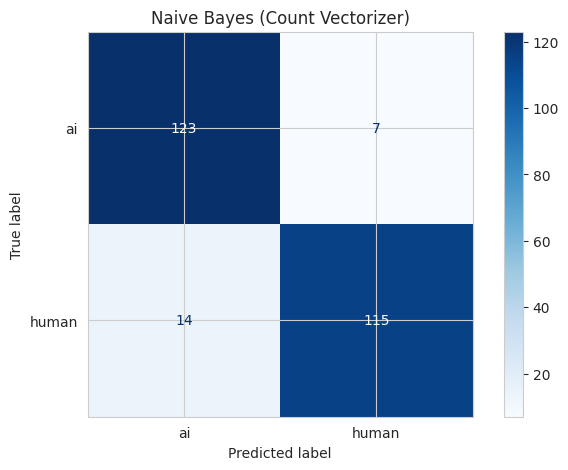

In [ ]:
nb_count = MultinomialNB()

evaluate_model(
    nb_count,
    X_train_count,
    X_test_count,
    y_train,
    y_test,
    "Naive Bayes",
    "Count Vectorizer"
)

Naive Bayes (TF-IDF)
Accuracy : 0.9151
Precision: 0.9159
Recall   : 0.9151
F1 Score : 0.9150

Classification Report

              precision    recall  f1-score   support

          ai       0.90      0.94      0.92       130
       human       0.93      0.89      0.91       129

    accuracy                           0.92       259
   macro avg       0.92      0.91      0.91       259
weighted avg       0.92      0.92      0.92       259



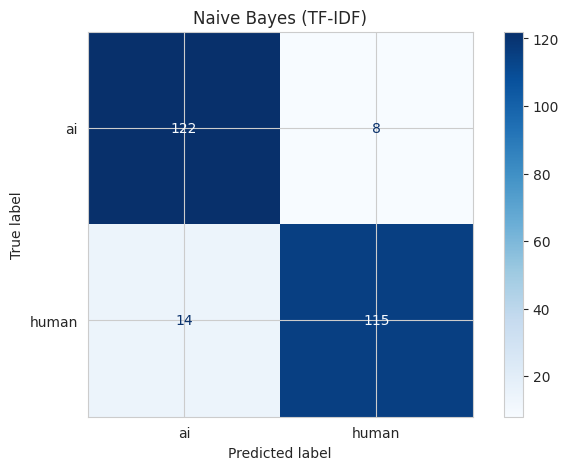

In [ ]:
nb_tfidf = MultinomialNB()

evaluate_model(
    nb_tfidf,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test,
    "Naive Bayes",
    "TF-IDF"
)

Logistic Regression (TF-IDF)
Accuracy : 0.9228
Precision: 0.9253
Recall   : 0.9228
F1 Score : 0.9227

Classification Report

              precision    recall  f1-score   support

          ai       0.89      0.96      0.93       130
       human       0.96      0.88      0.92       129

    accuracy                           0.92       259
   macro avg       0.93      0.92      0.92       259
weighted avg       0.93      0.92      0.92       259



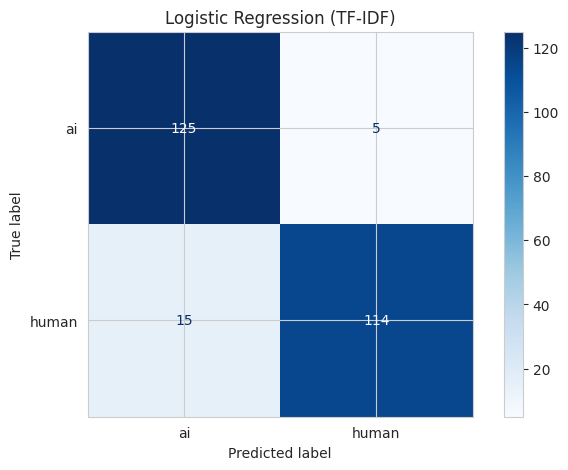

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42)

evaluate_model(
    lr,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test,
    "Logistic Regression",
    "TF-IDF"
)

Linear SVM (TF-IDF)
Accuracy : 0.9266
Precision: 0.9273
Recall   : 0.9266
F1 Score : 0.9266

Classification Report

              precision    recall  f1-score   support

          ai       0.91      0.95      0.93       130
       human       0.94      0.91      0.92       129

    accuracy                           0.93       259
   macro avg       0.93      0.93      0.93       259
weighted avg       0.93      0.93      0.93       259



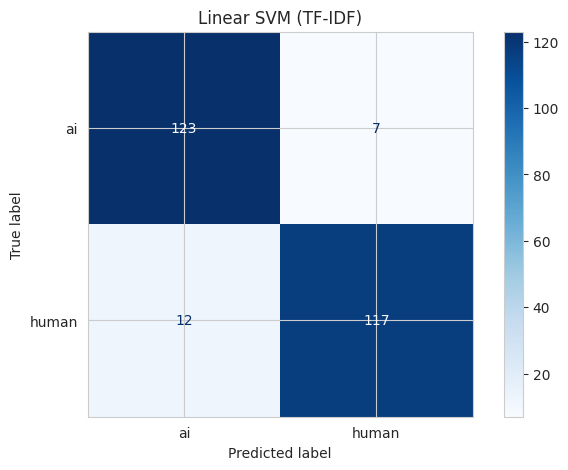

In [ ]:
svm = LinearSVC(random_state=42)

evaluate_model(
    svm,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test,
    "Linear SVM",
    "TF-IDF"
)

Decision Tree (TF-IDF)
Accuracy : 0.8687
Precision: 0.8759
Recall   : 0.8687
F1 Score : 0.8681

Classification Report

              precision    recall  f1-score   support

          ai       0.82      0.94      0.88       130
       human       0.93      0.80      0.86       129

    accuracy                           0.87       259
   macro avg       0.88      0.87      0.87       259
weighted avg       0.88      0.87      0.87       259



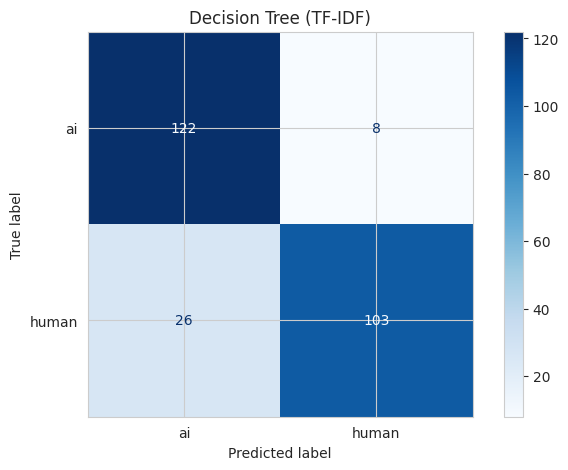

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

evaluate_model(
    dt,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test,
    "Decision Tree",
    "TF-IDF"
)

Random Forest (TF-IDF)
Accuracy : 0.8880
Precision: 0.8948
Recall   : 0.8880
F1 Score : 0.8875

Classification Report

              precision    recall  f1-score   support

          ai       0.84      0.95      0.90       130
       human       0.95      0.82      0.88       129

    accuracy                           0.89       259
   macro avg       0.89      0.89      0.89       259
weighted avg       0.89      0.89      0.89       259



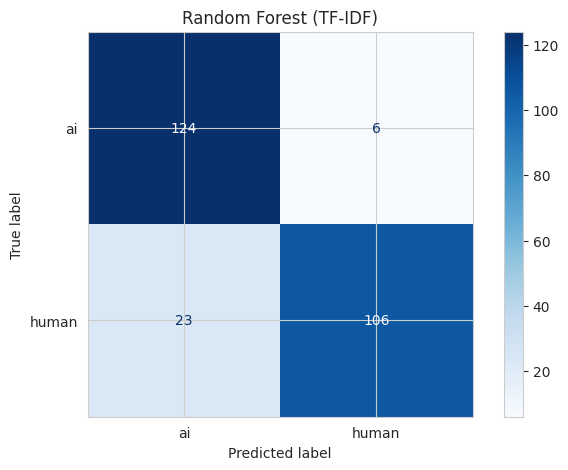

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

evaluate_model(
    rf,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test,
    "Random Forest",
    "TF-IDF"
)

In [ ]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

,Model,Representation,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,TF-IDF,0.926641,0.927267,0.926641,0.926608
1,Logistic Regression,TF-IDF,0.922780,0.925294,0.922780,0.922653
2,Naive Bayes,Count Vectorizer,0.918919,0.920130,0.918919,0.918851
3,Naive Bayes,TF-IDF,0.915058,0.915936,0.915058,0.915005
4,Random Forest,TF-IDF,0.888031,0.894784,0.888031,0.887518
5,Decision Tree,TF-IDF,0.868726,0.875926,0.868726,0.868053


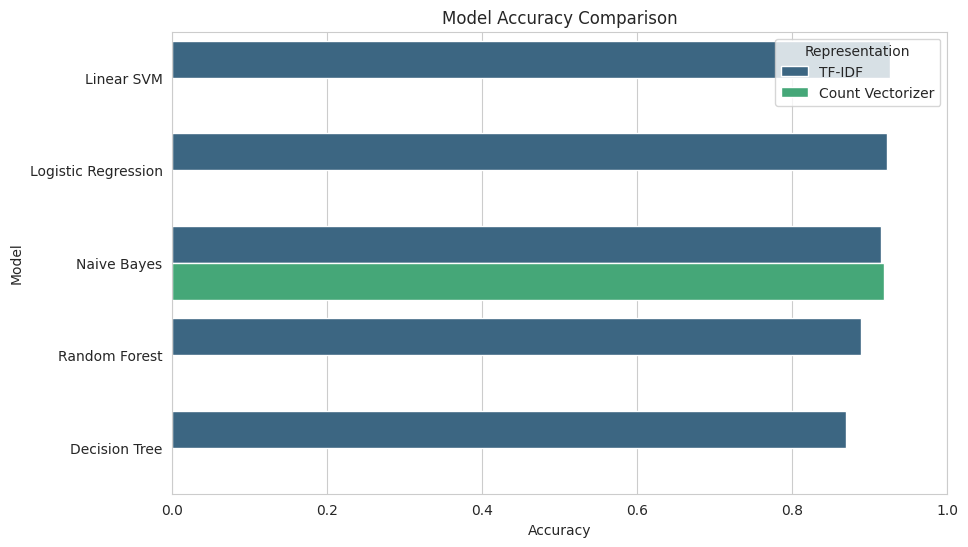

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df.sort_values("Accuracy", ascending=False),
    x="Accuracy",
    y="Model",
    hue="Representation",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

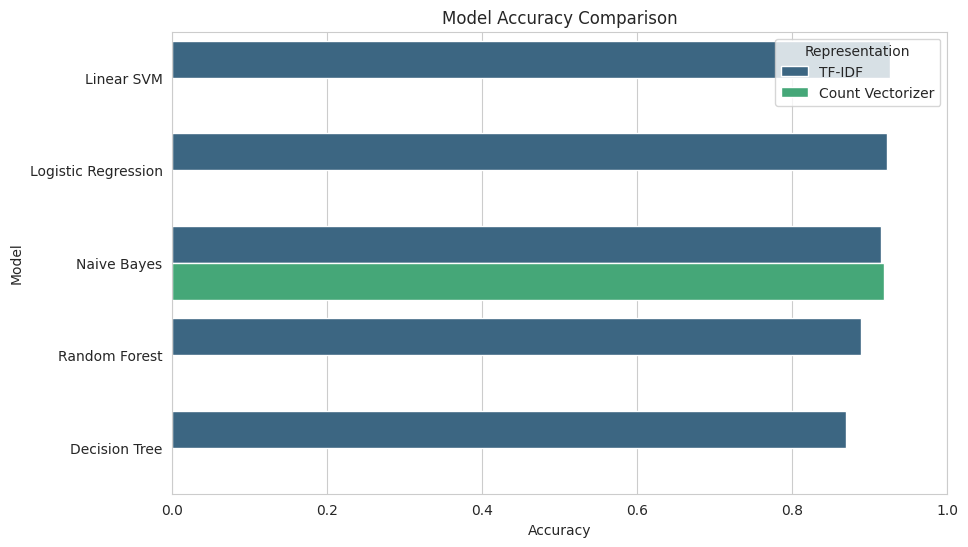

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df.sort_values("Accuracy", ascending=False),
    x="Accuracy",
    y="Model",
    hue="Representation",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

# Performance Analysis

The performance of six machine learning experiments was compared using Accuracy, Precision, Recall, and F1-score.

The comparison shows that **Linear Support Vector Machine (SVM) with TF-IDF** achieved the highest performance, followed closely by **Logistic Regression with TF-IDF**.

Naive Bayes also performed well, especially when combined with Count Vectorizer, making it a strong baseline model for text classification.

Decision Tree and Random Forest achieved comparatively lower performance because tree-based algorithms generally struggle with sparse and high-dimensional text data produced by Count Vectorizer and TF-IDF.

Overall, TF-IDF proved to be a more effective text representation than raw word counts for most machine learning models.

In [ ]:
best_model = results_df.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]

print("="*50)
print("BEST MODEL")
print("="*50)

print(f"Model          : {best_model['Model']}")
print(f"Representation : {best_model['Representation']}")
print(f"Accuracy       : {best_model['Accuracy']:.4f}")
print(f"Precision      : {best_model['Precision']:.4f}")
print(f"Recall         : {best_model['Recall']:.4f}")
print(f"F1 Score       : {best_model['F1 Score']:.4f}")

BEST MODEL
Model          : Linear SVM
Representation : TF-IDF
Accuracy       : 0.9266
Precision      : 0.9273
Recall         : 0.9266
F1 Score       : 0.9266


In [ ]:
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df.style.background_gradient(
    cmap="Greens",
    subset=["Accuracy","Precision","Recall","F1 Score"]
)

,Model,Representation,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,TF-IDF,0.926641,0.927267,0.926641,0.926608
1,Logistic Regression,TF-IDF,0.922780,0.925294,0.922780,0.922653
2,Naive Bayes,Count Vectorizer,0.918919,0.920130,0.918919,0.918851
3,Naive Bayes,TF-IDF,0.915058,0.915936,0.915058,0.915005
4,Random Forest,TF-IDF,0.888031,0.894784,0.888031,0.887518
5,Decision Tree,TF-IDF,0.868726,0.875926,0.868726,0.868053


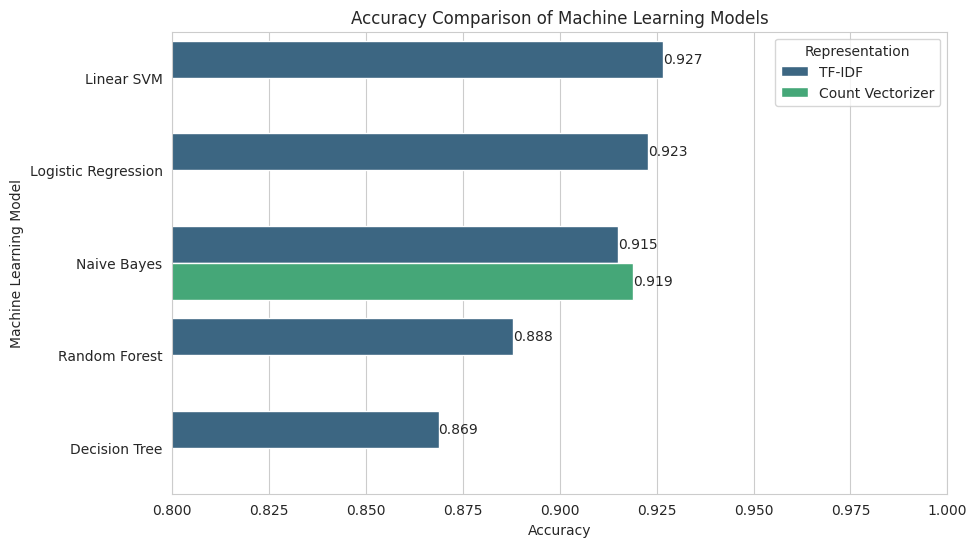

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    hue="Representation",
    palette="viridis"
)

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Accuracy")
plt.ylabel("Machine Learning Model")

plt.xlim(0.80,1)

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt="%.3f")

plt.show()

# Understanding N-Grams and Markov Models

## What is a Unigram?

A unigram is a single word treated as an independent feature.

Example:

```
Machine
Learning
Models
```

---

## What is a Bigram?

A bigram consists of two consecutive words.

Example:

```
Machine Learning

Learning Models
```

---

## What is a Trigram?

A trigram consists of three consecutive words.

Example:

```
Machine Learning Models
```

---

## How do N-Grams Improve Text Classification?

N-grams capture relationships between neighboring words instead of treating every word independently.

For example:

```
good
```

and

```
not good
```

contain the same word **good**, but they have completely different meanings.

Using bigrams allows machine learning models to understand this context and improve classification accuracy.

---

## Relationship between N-Grams and Markov Models

Markov Models predict the probability of the next word based on one or more previous words.

Similarly, N-Grams represent sequences of consecutive words and capture local contextual information.

Although this project does not build a complete Markov Model, the use of unigram, bigram, and trigram representations follows the same fundamental idea of modeling word sequences to better understand natural language.

In [ ]:
# Save the Best Model

best_vectorizer = tfidf
best_classifier = svm

In [ ]:
def predict_text(text):

    cleaned = preprocess_text(text)

    vector = best_vectorizer.transform([cleaned])

    prediction = best_classifier.predict(vector)[0]

    print("="*60)
    print("Input Text:\n")
    print(text)
    print("="*60)
    print("Prediction :", prediction)

## TESTS

In [ ]:
predict_text(
"""
Artificial Intelligence has revolutionized healthcare by enabling
early disease diagnosis and personalized treatment through machine
learning algorithms.
"""
)

Input Text:


Artificial Intelligence has revolutionized healthcare by enabling
early disease diagnosis and personalized treatment through machine
learning algorithms.

Prediction : ai


In [ ]:
predict_text(
"""
I forgot my umbrella today, so I got completely soaked while walking
back home from the market.
"""
)

Input Text:


I forgot my umbrella today, so I got completely soaked while walking
back home from the market.

Prediction : ai
